# LumenY 6 â€” 3-Quantile Regression (1H) â€” All 15 Pairs

Same architecture as `notebooks_5.1/03_model_training.ipynb` but trained on **features_9**
(microstructure + session/time + contextual features + pair correlations ).

**Models saved to:** `backend/models_9/3_quants/`

In [27]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import joblib
import warnings
import gc
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import mean_pinball_loss

FEATURES_DIR = Path('../backend/data/features_9')
MODELS_DIR   = Path('../backend/models_9/mfe_q50_8h')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

QUANTILES = [0.50]
QUANTILE_NAMES = ['Q50']

# -- CRITICAL: Training cutoff --
TRAIN_END = '2024-06-30'
AVG_SPREAD = 0.00028

print('Ready.')
print(f'Model to train: Q50 median regression on MFE (max favorable excursion)')
print(f'Training cutoff: {TRAIN_END}')

Ready.
Model to train: Q50 median regression on MFE (max favorable excursion)
Training cutoff: 2024-06-30


## 1. Load Microstructure Dataset

In [28]:
# Load features_9 (all 15 pairs)
dfs = []
for f in sorted(FEATURES_DIR.glob('*_features.parquet')):
    tmp = pd.read_parquet(f)
    dfs.append(tmp)

df_features = pd.concat(dfs).sort_index()
del dfs
print(f'features_9: {df_features.shape}')

# Load labels from features_2 (majors) + features_3 (crosses)
df_labels_maj = pd.read_parquet(Path('../backend/data/features_2') / 'all_pairs_microstructure.parquet')[['pair', 'label_1H', 'label_4H']]
df_labels_cro = pd.read_parquet(Path('../backend/data/features_3') / 'all_pairs_microstructure.parquet')[['pair', 'label_1H', 'label_4H']]
df_labels = pd.concat([df_labels_maj, df_labels_cro]).sort_index()
del df_labels_maj, df_labels_cro
print(f'labels:     {df_labels.shape}')

# Join on (timestamp index + pair) to avoid cartesian product
df_features = df_features.reset_index()
df_labels   = df_labels.reset_index()
df = pd.merge(df_features, df_labels, on=[df_features.columns[0], 'pair'], how='inner')
df = df.set_index(df.columns[0]).sort_index()
del df_features, df_labels
print(f'merged:     {df.shape}')

# MFE target: max favorable excursion resolving within 8h
# Only keep bars where the trail stop triggered within 8h — mfe_long/short_pips is then the true 8h MFE
df['valid_long']  = df['trail_long_bars']  <= 8
df['valid_short'] = df['trail_short_bars'] <= 8
df['mfe_long_8h']  = df['mfe_long_pips'].where(df['valid_long'])
df['mfe_short_8h'] = df['mfe_short_pips'].where(df['valid_short'])
df['mfe_max'] = df[['mfe_long_8h', 'mfe_short_8h']].max(axis=1)
print(f'8h filter: {df["mfe_max"].notna().mean():.1%} of bars have valid 8h MFE')

label_cols   = [c for c in df.columns if c.startswith('label_')] + ['mfe_long_pips', 'mfe_short_pips', 'mfe_max', 'mfe_long_8h', 'mfe_short_8h', 'valid_long', 'valid_short']
# Drop pure volatility/scale features — force model to use microstructure signal only
VOL_DROP = [
    'atr_24', 'atr_72', 'atr_6', 'atr_ratio_6_24', 'atr_ratio_6_72',
    'vol_regime_5d', 'vol_regime_10d', 'vol_trend',
    'range_width_24', 'range_width_48', 'range_width_5d',
    'rv_zscore_24',
]
drop_cols    = label_cols + ['pair', 'trail_long_bars', 'trail_short_bars', 'trail_stop_pips', 'mfe_atr_24'] + VOL_DROP
feature_cols = [c for c in df.columns if c not in drop_cols]

TARGET_COL = 'mfe_max'

# Split
df_train = df[df.index <= TRAIN_END].copy()
df_test  = df[df.index > TRAIN_END].copy()

print(f'\nFull dataset:  {df.shape}  ({df.index.min().date()} to {df.index.max().date()})')
print(f'Features:      {len(feature_cols)} (hour_sin/cos excluded)')
print(f'Train set:     {len(df_train):,} rows  ({df_train.index.min().date()} to {df_train.index.max().date()})')
print(f'Test set:      {len(df_test):,} rows  ({df_test.index.min().date()} to {df_test.index.max().date()})')
print(f'All pairs:     {sorted(df["pair"].unique())}')
print(f'\nTarget stats (train):')
print(df_train[TARGET_COL].describe())

features_9: (1518020, 327)
labels:     (1518020, 3)
merged:     (1518020, 329)
8h filter: 86.2% of bars have valid 8h MFE

Full dataset:  (1518020, 334)  (2009-09-25 to 2025-12-31)
Features:      308 (hour_sin/cos excluded)
Train set:     1,378,758 rows  (2009-09-25 to 2024-06-28)
Test set:      139,262 rows  (2024-06-30 to 2025-12-31)
All pairs:     ['AUDJPY', 'AUDNZD', 'AUDUSD', 'CADJPY', 'CHFJPY', 'EURAUD', 'EURGBP', 'EURJPY', 'EURUSD', 'GBPJPY', 'GBPUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY']

Target stats (train):
count    1.189335e+06
mean     3.146554e+01
std      4.344048e+01
min      0.000000e+00
25%      1.430000e+01
50%      2.460000e+01
75%      3.950000e+01
max      1.010902e+04
Name: mfe_max, dtype: float64


## 2. Walk-Forward Splits

In [29]:
def walk_forward_splits(n, n_splits=5, test_ratio=0.1):
    """Expanding window walk-forward splits. All within training data."""
    test_size = int(n * test_ratio)
    splits = []
    for i in range(n_splits):
        test_start = int(n * 0.5) + i * (int(n * 0.5) // n_splits)
        test_end   = test_start + test_size
        if test_end > n:
            break
        splits.append((list(range(0, test_start)), list(range(test_start, test_end))))
    return splits

splits = walk_forward_splits(len(df_train))
print(f'Walk-forward splits: {len(splits)} (all within training set, before {TRAIN_END})')
for i, (train_idx, test_idx) in enumerate(splits):
    print(f'  Fold {i+1}: Train -> {df_train.index[train_idx[-1]].date()} ({len(train_idx):,}) | '
          f'Test {df_train.index[test_idx[0]].date()} -> {df_train.index[test_idx[-1]].date()} ({len(test_idx):,})')

Walk-forward splits: 5 (all within training set, before 2024-06-30)
  Fold 1: Train -> 2017-02-28 (689,379) | Test 2017-02-28 -> 2018-08-21 (137,875)
  Fold 2: Train -> 2018-08-21 (827,254) | Test 2018-08-21 -> 2020-02-20 (137,875)
  Fold 3: Train -> 2020-02-20 (965,129) | Test 2020-02-20 -> 2021-08-25 (137,875)
  Fold 4: Train -> 2021-08-25 (1,103,004) | Test 2021-08-25 -> 2023-01-25 (137,875)
  Fold 5: Train -> 2023-01-25 (1,240,879) | Test 2023-01-25 -> 2024-06-28 (137,875)


## 3. LightGBM Quantile Config

In [30]:
def get_lgbm_params(quantile):
    return {
        'objective':         'quantile',
        'alpha':             quantile,
        'metric':            'quantile',
        'boosting_type':     'gbdt',
        'n_estimators':      10000,
        'learning_rate':     0.02,
        'num_leaves':        64,
        'max_depth':         6,
        'min_child_samples': 50,
        'feature_fraction':  0.7,
        'bagging_fraction':  0.8,
        'bagging_freq':      5,
        'reg_alpha':         0.1,
        'reg_lambda':        0.1,
        'random_state':      42,
        'n_jobs':            -1,
        'verbose':           -1,
        'device':            'gpu',
    }

print('Params ready. objective=quantile with pinball loss.')

Params ready. objective=quantile with pinball loss.


## 4. Train 3 Quantile Models (Walk-Forward CV + Final)

In [31]:
y_all = df_train[TARGET_COL]
valid_mask = y_all.notna()
X_clean = df_train[feature_cols][valid_mask].ffill().fillna(0)
y_clean = y_all[valid_mask]

print(f'Training samples: {len(X_clean):,} (all before {TRAIN_END})')
print(f'Target mean: {y_clean.mean():.6f}, std: {y_clean.std():.6f}')

splits = walk_forward_splits(len(X_clean))
oof_preds  = {q: np.full(len(X_clean), np.nan) for q in QUANTILES}
best_iters = {q: [] for q in QUANTILES}
cv_pinball = {q: [] for q in QUANTILES}

for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    print(f'\nTraining {q_name} (alpha={q})...')
    params = get_lgbm_params(q)

    for fold, (train_idx, test_idx) in enumerate(splits):
        X_tr, y_tr = X_clean.iloc[train_idx], y_clean.iloc[train_idx]
        X_te, y_te = X_clean.iloc[test_idx], y_clean.iloc[test_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

        preds = model.predict(X_te)
        oof_preds[q][test_idx] = preds
        cv_pinball[q].append(mean_pinball_loss(y_te, preds, alpha=q))
        best_iters[q].append(model.best_iteration_)

    print(f'  CV Pinball: {np.mean(cv_pinball[q]):.6f} | Best iters: {best_iters[q]}')
    del model; gc.collect()

# Train final models on ALL training data
print(f'\n{"="*55}')
print('Training final models on full training set...')
for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    avg_iter = max(50, int(np.mean(best_iters[q])))
    params = get_lgbm_params(q)
    final_model = lgb.LGBMRegressor(**{**params, 'n_estimators': avg_iter})
    final_model.fit(X_clean, y_clean)

    q_int = int(q * 100)
    joblib.dump({
        'model': final_model,
        'quantile': q,
        'horizon': '1H',
        'feature_cols': feature_cols,
        'train_end': TRAIN_END,
        'avg_spread': AVG_SPREAD,
        'cv_pinball': np.mean(cv_pinball[q]),
        'n_iters': avg_iter,
    }, MODELS_DIR / f'model_1H_Q{q_int}.joblib')

    size_mb = (MODELS_DIR / f'model_1H_Q{q_int}.joblib').stat().st_size / 1024 / 1024
    print(f'  {q_name}: {avg_iter} iters, pinball={np.mean(cv_pinball[q]):.6f}, saved ({size_mb:.1f} MB)')
    del final_model; gc.collect()

print(f'\nAll 3 models saved to {MODELS_DIR}')

Training samples: 1,189,335 (all before 2024-06-30)
Target mean: 31.465540, std: 43.440475

Training Q50 (alpha=0.5)...
  CV Pinball: 7.779383 | Best iters: [1097, 1125, 2078, 2377, 2330]

Training final models on full training set...
  Q50: 1801 iters, pinball=7.779383, saved (9.8 MB)

All 3 models saved to ..\backend\models_9\mfe_q50_8h


## 5. Quantile Coverage (OOF Calibration)

OOF Quantile Coverage:
Quantile   Target     Actual     Gap
------------------------------------------
Q50        0.50       0.540      +0.040  NEEDS CALIBRATION


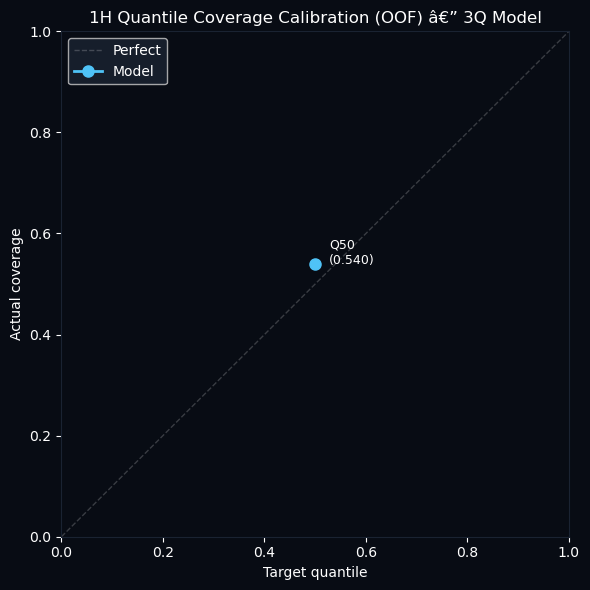

In [32]:
valid_oof = ~np.isnan(oof_preds[QUANTILES[0]])
y_oof = y_clean.values[valid_oof]

print(f'OOF Quantile Coverage:')
print(f'{"Quantile":<10} {"Target":<10} {"Actual":<10} {"Gap"}')
print(f'{"-"*42}')

for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    preds_oof = oof_preds[q][valid_oof]
    coverage  = np.mean(y_oof <= preds_oof)
    gap       = coverage - q
    flag      = 'OK' if abs(gap) < 0.03 else 'NEEDS CALIBRATION'
    print(f'{q_name:<10} {q:<10.2f} {coverage:<10.3f} {gap:+.3f}  {flag}')

# Calibration plot
fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor('#080c14')
ax.set_facecolor('#080c14')

targets = QUANTILES
actuals = [np.mean(y_oof <= oof_preds[q][valid_oof]) for q in QUANTILES]

ax.plot([0,1], [0,1], '--', color=(1,1,1,0.2), linewidth=1, label='Perfect')
ax.plot(targets, actuals, 'o-', color='#4fc3f7', linewidth=2, markersize=8, label='Model')
for t, a, name in zip(targets, actuals, QUANTILE_NAMES):
    ax.annotate(f'{name}\n({a:.3f})', (t, a), textcoords='offset points',
                xytext=(10, 0), color='white', fontsize=9)

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Target quantile', color='white')
ax.set_ylabel('Actual coverage', color='white')
ax.set_title('1H Quantile Coverage Calibration (OOF) â€” 3Q Model', color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#1a2332', labelcolor='white')
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')
plt.tight_layout()
plt.show()

## 6. Test Set Evaluation

Load final models, predict all 3 quantiles on unseen test set.

**Trading rules:**
- Direction = sign(Q50)
- Trade only when |Q50| > spread
- PnL per trade = direction Ã— actual_return - spread

In [33]:
# -- Prepare test data --
X_test = df_test[feature_cols].ffill().fillna(0)
y_test = df_test[TARGET_COL]
valid_test = y_test.notna()
X_test_clean = X_test[valid_test]
# -- Prepare test data --
X_test = df_test[feature_cols].ffill().fillna(0)
y_test = df_test[TARGET_COL]
valid_test = y_test.notna()
X_test_clean = X_test[valid_test]
y_test_clean = y_test[valid_test]

# -- Predict Q50 --
q_int = int(0.50 * 100)
bundle = joblib.load(MODELS_DIR / f'model_1H_Q{q_int}.joblib')
q50_preds = bundle['model'].predict(X_test_clean)
print(f'Q50: mean={q50_preds.mean():.6f}, std={q50_preds.std():.6f}')

# -- Build results DataFrame --
results = pd.DataFrame({
    'actual_mfe': y_test_clean.values,
    'Q50': q50_preds,
    'pair': df_test.loc[valid_test, 'pair'].values,
}, index=y_test_clean.index)

print(f'\nTest set: {len(results):,} rows ({results.index.min().date()} -> {results.index.max().date()})')
print(f'Actual MFE â€” mean: {results["actual_mfe"].mean():.5f}  std: {results["actual_mfe"].std():.5f}')

# -- Regression quality at different Q50 thresholds --
from sklearn.metrics import mean_absolute_error

thresholds = thresholds = [0, 10, 20, 30, 40, 50, 70, 100]

print(f'\n{"Q50 threshold":>15} {"Trades":>8} {"% kept":>7} {"MAE":>10} {"corr":>8} {"avg actual":>12} {"avg pred":>12}')
print('-' * 80)

for thresh in thresholds:
    mask = results['Q50'] > thresh
    if mask.sum() < 50:
        continue
    s = results[mask]
    mae  = mean_absolute_error(s['actual_mfe'], s['Q50'])
    corr = np.corrcoef(s['actual_mfe'], s['Q50'])[0, 1]
    print(f'{thresh:>15.4f} {mask.sum():>8,} {mask.mean():>7.1%} {mae:>10.5f} {corr:>8.3f} {s["actual_mfe"].mean():>12.5f} {s["Q50"].mean():>12.5f}')

print(f'\nSpread cost: {AVG_SPREAD:.5f}')
print('Higher Q50 threshold = model only selects bars it predicts large moves on')


Q50: mean=32.600663, std=15.643452

Test set: 118,893 rows (2024-07-01 -> 2025-12-31)
Actual MFE â€” mean: 42.71125  std: 82.09750

  Q50 threshold   Trades  % kept        MAE     corr   avg actual     avg pred
--------------------------------------------------------------------------------
         0.0000  118,893  100.0%   24.45743    0.337     42.71125     32.60066
        10.0000  118,448   99.6%   24.52513    0.337     42.83094     32.69141
        20.0000   94,809   79.7%   28.16132    0.313     48.82450     36.72369
        30.0000   57,904   48.7%   35.10865    0.311     60.60504     44.33642
        40.0000   30,351   25.5%   46.49636    0.283     77.58382     53.08179
        50.0000   13,629   11.5%   64.83352    0.253    102.26151     63.66611
        70.0000    2,941    2.5%  123.94055    0.135    173.39227     87.22012
       100.0000      434    0.4%  217.99981   -0.038    259.50983    128.66929

Spread cost: 0.00028
Higher Q50 threshold = model only selects bars it pred

In [34]:
# -- Per-pair breakdown (Q50 > 30 pips filter) --
filtered = results[results['Q50'] > 30]

print(f'Per-pair results (Q50 > 30 pips):')
print(f'\n{"Pair":<10} {"Trades":>8} {"Avg MFE actual":>16} {"Avg MFE pred":>14} {"corr":>8}')
print('-' * 60)

for pair in sorted(filtered['pair'].unique()):
    p = filtered[filtered['pair'] == pair]
    corr = np.corrcoef(p['actual_mfe'], p['Q50'])[0, 1] if len(p) > 10 else 0
    print(f'{pair:<10} {len(p):>8,} {p["actual_mfe"].mean():>16.2f} {p["Q50"].mean():>14.2f} {corr:>8.3f}')

Per-pair results (Q50 > 30 pips):

Pair         Trades   Avg MFE actual   Avg MFE pred     corr
------------------------------------------------------------
AUDJPY        5,479            53.63          40.26    0.331
AUDNZD        4,001            83.96          49.87    0.280
AUDUSD          902            46.15          39.44    0.173
CADJPY        5,133            61.69          40.77    0.247
CHFJPY        7,514            89.12          56.70    0.377
EURAUD        7,028            63.35          41.74    0.264
EURGBP          824            63.28          41.35    0.233
EURJPY        7,400            47.67          43.85    0.229
EURUSD        1,007            37.76          36.37    0.264
GBPJPY        8,073            55.66          46.47    0.392
GBPUSD        1,870            35.89          34.66    0.413
NZDUSD          955            88.88          39.28    0.110
USDCAD          852            59.85          38.78   -0.044
USDCHF          880            35.94          37.9

## 7. Equity Curves

In [35]:
# MFE lift by Q50 decile
results['q50_decile'] = pd.qcut(results['Q50'], q=10, labels=False, duplicates='drop')
decile_stats = results.groupby('q50_decile').agg(
    trades=('actual_mfe', 'count'),
    avg_actual_mfe=('actual_mfe', 'mean'),
    avg_pred_mfe=('Q50', 'mean')
).reset_index()

print(f'{"Decile":>8} {"Trades":>8} {"Avg Pred MFE":>14} {"Avg Actual MFE":>16}')
print('-' * 50)
for _, row in decile_stats.iterrows():
    bar = '#' * int(row.avg_actual_mfe / 5)
    print(f'{int(row.q50_decile):>8} {int(row.trades):>8} {row.avg_pred_mfe:>14.1f} {row.avg_actual_mfe:>16.1f}  {bar}')
print('\nDecile 0 = lowest predicted MFE, Decile 9 = highest')

  Decile   Trades   Avg Pred MFE   Avg Actual MFE
--------------------------------------------------
       0    11890           14.2             16.5  ###
       1    11889           18.4             20.6  ####
       2    11889           21.4             25.9  #####
       3    11889           24.4             30.1  ######
       4    11890           27.7             34.0  ######
       5    11889           31.4             37.5  #######
       6    11889           35.5             42.1  ########
       7    11889           40.4             51.4  ##########
       8    11889           47.0             61.4  ############
       9    11890           65.5            107.5  #####################

Decile 0 = lowest predicted MFE, Decile 9 = highest


## 8. Feature Importance

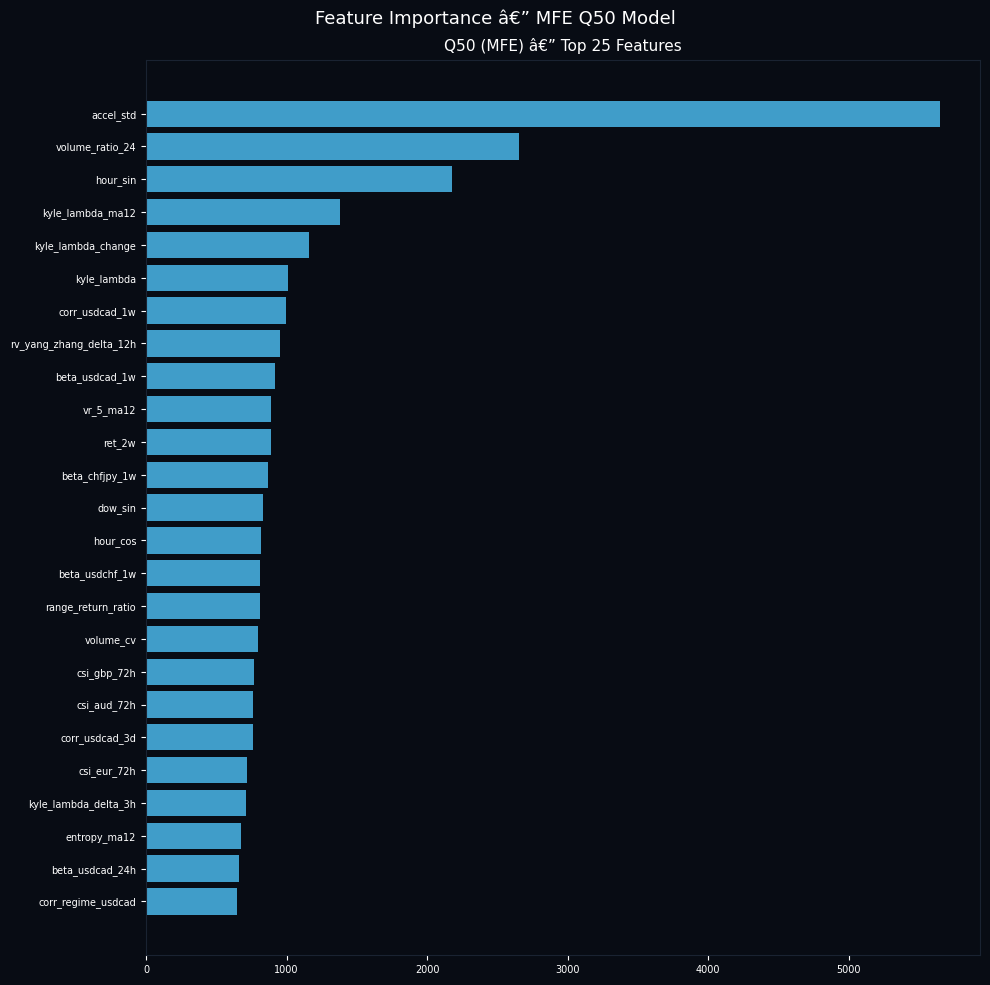

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
fig.patch.set_facecolor('#080c14')
ax.set_facecolor('#080c14')

bundle = joblib.load(MODELS_DIR / 'model_1H_Q50.joblib')
importance = pd.Series(bundle['model'].feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=True).tail(25)

ax.barh(importance.index, importance.values, color='#4fc3f7', alpha=0.8)
ax.tick_params(colors='white', labelsize=7)
ax.set_title('Q50 (MFE) â€” Top 25 Features', color='white', fontsize=11)
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

plt.suptitle('Feature Importance â€” MFE Q50 Model', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Diagnostics

Q50 coverage: 0.539 (target: 0.50)
Mean actual MFE: 42.71 pips
Mean pred  MFE: 32.60 pips
Overall corr:   0.337


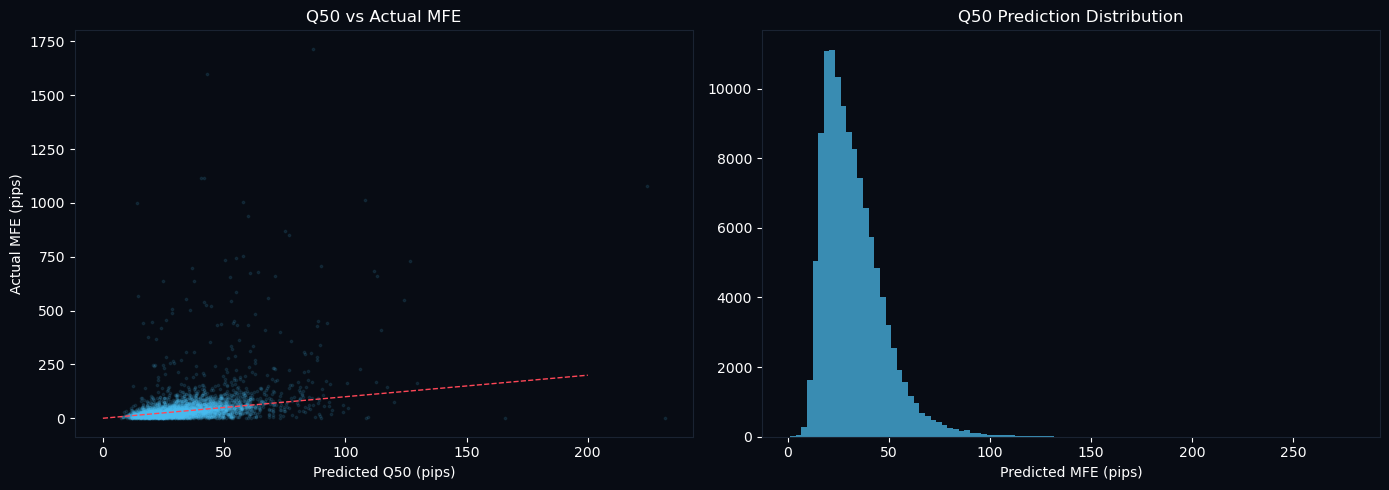

In [37]:
# Q50 coverage check
coverage = (results['actual_mfe'] <= results['Q50']).mean()
print(f'Q50 coverage: {coverage:.3f} (target: 0.50)')
print(f'Mean actual MFE: {results["actual_mfe"].mean():.2f} pips')
print(f'Mean pred  MFE: {results["Q50"].mean():.2f} pips')
print(f'Overall corr:   {np.corrcoef(results["actual_mfe"], results["Q50"])[0,1]:.3f}')

# Q50 vs actual MFE scatter
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#080c14')
for ax in axes:
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

sample = results.sample(min(5000, len(results)), random_state=42)
axes[0].scatter(sample['Q50'], sample['actual_mfe'], alpha=0.1, s=3, color='#4fc3f7')
axes[0].plot([0, 200], [0, 200], '--', color='#ff4757', linewidth=1)
axes[0].set_title('Q50 vs Actual MFE', color='white')
axes[0].set_xlabel('Predicted Q50 (pips)', color='white')
axes[0].set_ylabel('Actual MFE (pips)', color='white')

axes[1].hist(results['Q50'], bins=100, color='#4fc3f7', alpha=0.7, edgecolor='none')
axes[1].set_title('Q50 Prediction Distribution', color='white')
axes[1].set_xlabel('Predicted MFE (pips)', color='white')

plt.tight_layout()
plt.show()

## 11. Summary

In [38]:
print('=' * 70)
print('MFE Q50 MODEL â€” TRAINING COMPLETE')
print('=' * 70)

print(f'\nModels saved to: {MODELS_DIR.resolve()}')
for f in sorted(MODELS_DIR.glob('*.joblib')):
    print(f'  {f.name:<25} {f.stat().st_size / 1024 / 1024:.1f} MB')

print(f'\n-- CV Results --')
for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    print(f'  {q_name}: pinball={np.mean(cv_pinball[q]):.6f}, avg_iters={int(np.mean(best_iters[q]))}')

print(f'\n-- Test Set Results (UNSEEN, after {TRAIN_END}) --')
print(f'  Overall corr (Q50 vs actual MFE): {np.corrcoef(results["actual_mfe"], results["Q50"])[0,1]:.3f}')
print(f'  Mean actual MFE (all bars):        {results["actual_mfe"].mean():.2f} pips')
print(f'  Mean actual MFE (Q50>50):          {results[results["Q50"]>50]["actual_mfe"].mean():.2f} pips')
print(f'  Mean actual MFE (Q50>70):          {results[results["Q50"]>70]["actual_mfe"].mean():.2f} pips')

print(f'\nTest period: {results.index.min().date()} -> {results.index.max().date()}')
print(f'Training cutoff: {TRAIN_END}')
print(f'Features: {len(feature_cols)}')

MFE Q50 MODEL â€” TRAINING COMPLETE

Models saved to: C:\Users\noual\lumeny\backend\models_9\mfe_q50_8h
  model_1H_Q50.joblib       9.8 MB

-- CV Results --
  Q50: pinball=7.779383, avg_iters=1801

-- Test Set Results (UNSEEN, after 2024-06-30) --
  Overall corr (Q50 vs actual MFE): 0.337
  Mean actual MFE (all bars):        42.71 pips
  Mean actual MFE (Q50>50):          102.26 pips
  Mean actual MFE (Q50>70):          173.39 pips

Test period: 2024-07-01 -> 2025-12-31
Training cutoff: 2024-06-30
Features: 308


In [39]:
# Trades per hour of day (Q50 > 50 filter)
by_hour = (
    results[results['Q50'] > 50]
    .assign(hour=lambda x: x.index.hour)
    .groupby('hour')
    .agg(trades=('actual_mfe', 'count'), avg_actual_mfe=('actual_mfe', 'mean'), avg_pred=('Q50', 'mean'))
)
total = by_hour['trades'].sum()

print(f'{"Hour":>5} {"Trades":>8} {"% Total":>8} {"Avg Actual MFE":>16} {"Avg Pred MFE":>14}')
print('-' * 57)
for hour, row in by_hour.iterrows():
    bar = '#' * int(row.trades / total * 40)
    print(f'{hour:>5} {int(row.trades):>8} {row.trades/total*100:>7.1f}% {row.avg_actual_mfe:>16.1f} {row.avg_pred:>14.1f}  {bar}')
print('-' * 57)
print(f'{"TOTAL":>5} {int(total):>8}')


 Hour   Trades  % Total   Avg Actual MFE   Avg Pred MFE
---------------------------------------------------------
    0      307     2.3%             81.6           60.1  
    1      324     2.4%             72.0           59.3  
    2      246     1.8%             73.6           59.2  
    3      262     1.9%             78.7           60.6  
    4      433     3.2%             72.7           60.2  #
    5      602     4.4%             75.1           59.2  #
    6      694     5.1%             74.1           59.4  ##
    7      665     4.9%             74.2           59.4  #
    8      600     4.4%             74.1           59.2  #
    9      543     4.0%             75.2           59.2  #
   10      514     3.8%             69.8           59.5  #
   11      503     3.7%             68.3           59.7  #
   12      525     3.9%             81.6           59.3  #
   13      712     5.2%            108.1           60.5  ##
   14      835     6.1%            117.0           61.6  ##
  